<a href="https://colab.research.google.com/github/AdrianP428/DSRP_Project_MMF/blob/main/DSRP_Project_AP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [54]:
df = pd.read_csv('lendingclub_loans_clean.csv')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   emp_title                         9167 non-null   object 
 2   emp_length                        9183 non-null   float64
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    9976 non-null   float64
 8   debt_to_income_joint              1495 non-null   float64
 9   delinq_2y                         10000 non-null  int64  
 10  months_since_last_delinq          4342 non-null   float64
 11  earliest_credit_line              10000 non-null  int64  
 12  inqui

In [56]:
df.head()

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,debt_to_income_joint,delinq_2y,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,0,...,C3,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,0,...,C1,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,0,...,D1,<bound method PandasDelegate._add_delegate_acc...,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,0,...,A3,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,37.66,0,...,C3,<bound method PandasDelegate._add_delegate_acc...,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [57]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,
37,supplies clerk,10.0,NJ,MORTGAGE,70000.0,Verified,17.06,13.27,0,102.0,1988,2,21,14,363649,29954,0,0,102.0,0,0,3,4,7.0,14,0.0,0,3,12900,15,10,7,2,95.2,0,0,car,joint,24000,60,15.04,571.47,C4,<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000001BE9CDCE8B0>>,In Grace Period,whole,Cash,23455.27,1102.83,544.73,558.10,0.0,1
99,owner,10.0,MN,MORTGAGE,23000.0,Verified,49.58,19.87,0,59.0,1994,2,31,11,44927,29553,0,1,59.0,0,0,1,3,0.0,10,0.0,0,7,14700,17,10,7,2,96.0,0,1,credit_card,joint,15000,60,20.00,397.41,D4,<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000001BE9CDCE8B0>>,Current,whole,Cash,14395.45,1572.97,604.55,968.42,0.0,1
130,military officer captain,10.0,GA,RENT,145000.0,Verified,14.66,14.98,0,38.0,2003,0,29,11,206996,61746,0,0,47.0,0,0,3,4,23.0,11,0.0,0,4,11000,10,5,4,3,72.4,0,0,debt_consolidation,joint,40000,36,6.72,1229.97,A3,<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000001BE9CDCE8B0>>,Current,whole,Cash,35942.19,4890.01,4057.81,832.20,0.0,1
214,realtor / assistant,5.0,NJ,MORTGAGE,80000.0,Not Verified,18.39,11.77,0,56.0,1993,3,27,14,531782,81876,0,0,76.0,0,0,4,5,1.0,14,0.0,0,2,18200,16,9,6,3,74.1,0,0,credit_card,joint,14000,60,9.44,293.62,B1,<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000001BE9CDCE8B0>>,Current,whole,Cash,13068.02,1460.76,931.98,528.78,0.0,1
352,manager,10.0,TX,MORTGAGE,120000.0,Verified,7.81,15.15,0,36.0,1999,0,8,4,249410,42153,0,0,39.0,0,0,1,1,15.0,4,0.0,0,0,3000,3,2,0,3,75.0,0,0,debt_consolidation,joint,25000,36,7.35,775.94,A4,<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000001BE9CDCE8B0>>,Current,whole,Cash,21847.54,3859.28,3152.46,706.82,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9821,management,10.0,AZ,MORTGAGE,88000.0,Source Verified,32.28,24.13,0,60.0,2003,1,33,11,418826,73294,0,0,60.0,0,0,3,6,7.0,11,0.0,0,4,38500,13,7,5,5,90.6,0,0,home_improvement,joint,18625,60,10.42,399.59,B3,<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000001BE9CDCE8B0>>,Current,whole,Cash,17414.85,1987.17,1210.15,777.02,0.0,1
9877,charger operator,9.0,MN,MORTGAGE,31000.0,Verified,1.94,15.41,1,7.0,2006,2,29,7,277650,4145,0,0,30.0,0,0,1,4,11.0,7,0.0,0,1,

In [58]:
df = df.drop(columns = ['issue_month'])

In [59]:
df['has_prior_delinq'] = df['months_since_last_delinq'].notna().astype(int)
df['months_since_last_delinq'] = df['months_since_last_delinq'].fillna(999)

df['has_90d_late'] = df['months_since_90d_late'].notna().astype(int)
df['months_since_90d_late'].fillna(999)

df['has_recent_inquiry'] = df['months_since_last_credit_inquiry'].notna().astype(int)
df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].fillna(999)

df['emp_length_missing'] = df['emp_length'].isna().astype(int)
df['emp_length'] = df['emp_length'].fillna(0)

In [60]:
df['dti_effective'] = df['debt_to_income_joint'].fillna(df['debt_to_income'])
df['df_missing'] = df['dti_effective'].isna().astype(int)
df['dti_effective'] = df['dti_effective'].fillna(df['dti_effective'].median())

In [61]:

df = df[df['dti_effective'] <= 100]
df = df[df['annual_income'] >= 5000]


In [67]:
grade = {"A1": 1, 'A2': 2, 'A3': 3, 'A4' : 4, 'A5' : 5, 'B1': 6, 'B2' : 7, 'B3' : 8, 'B4' : 9, 'B5' : 10, 'C1' : 11, 'C2' : 12, 'C3' : 13, 'C4' : 14, 'C5' : 15, 'D1' : 16, 'D2' : 17, 'D3' : 18, 'D4' : 19, 'D5' : 20, 'E1' : 21, 'E2' : 22, 'E3': 23, 'E4' : 24, 'E5' : 25, 'F1' : 26, 'F2': 27, 'F3' : 28, 'F4' : 29, 'F5': 30, 'G1': 31, 'G2' : 32, 'G3': 33, 'G4': 34, 'G5': 35}
df['grade_num'] = df['sub_grade'].map(grade)
df['grade_letter'] = df['sub_grade'].str[0]

In [68]:
print(df['dti_effective'].corr(df['grade_num']))

0.22161672727962847


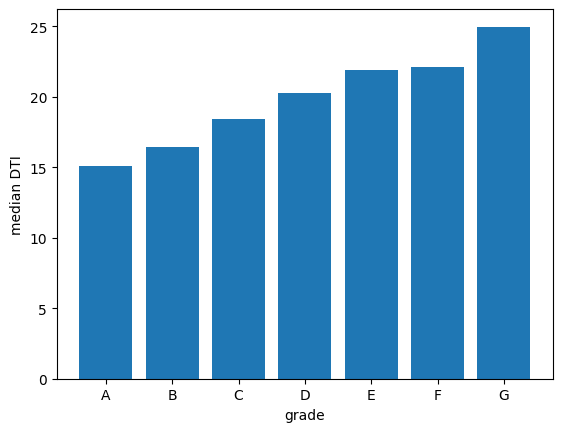

In [69]:
g = df.groupby('grade_letter')['dti_effective'].median()
x = g.index
y = g.values

plt.bar(x, y)
plt.xlabel('grade')
plt.ylabel('median DTI')
plt.show()

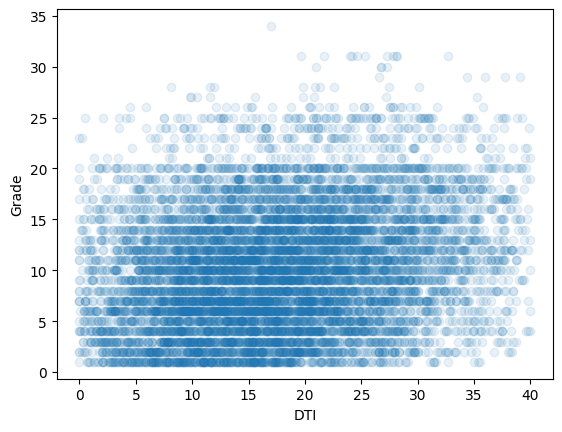

In [72]:
plt.scatter(df['dti_effective'], df['grade_num'], alpha = 0.1)
plt.xlabel('DTI')
plt.ylabel('Grade')
plt.show()

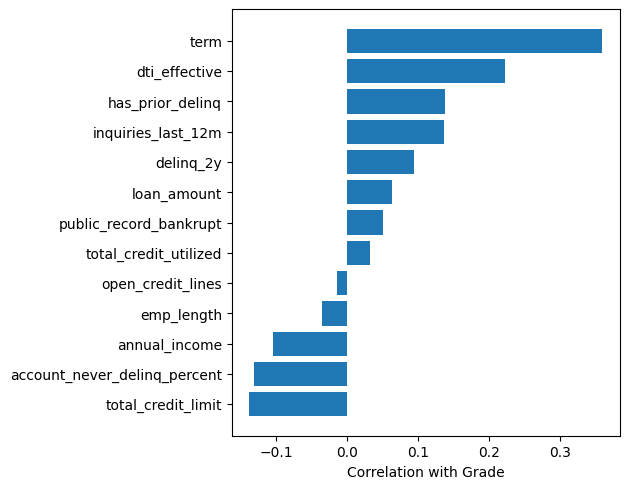

In [83]:
cols = ['dti_effective', 'annual_income', 'loan_amount', 'term', 'has_prior_delinq', 'inquiries_last_12m', 'delinq_2y', 'public_record_bankrupt', 'total_credit_utilized', 'total_credit_limit', 'open_credit_lines', 'emp_length', 'account_never_delinq_percent']
p = df[cols + ['grade_num']].corr()['grade_num'].drop('grade_num').sort_values()
plt.barh(p.index, p.values)
plt.tight_layout()
plt.xlabel('Correlation with Grade')
plt.show()

#Negative value means better grade and positive is worse grade

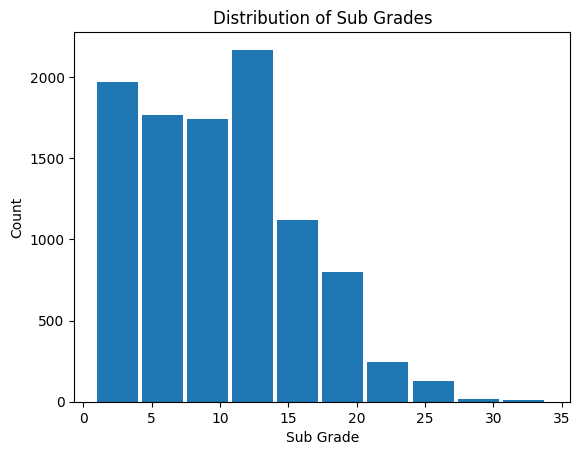

In [97]:
df['grade_num'].plot(kind = 'hist', width = 3)
plt.title("Distribution of Sub Grades")
plt.xlabel('Sub Grade')
plt.ylabel('Count')

plt.show()

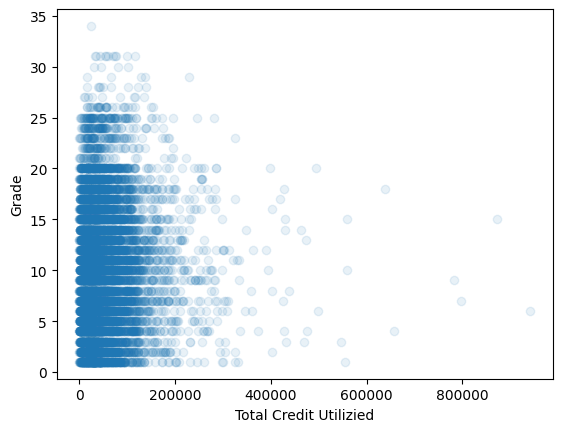

In [101]:
plt.scatter(df['total_credit_utilized'], df['grade_num'], alpha = 0.1)
plt.xlabel('Total Credit Utilizied')
plt.ylabel('Grade')
plt.show()